## Setup & Configuration

In [1]:
%pip install pandas scikit-learn faker

Note: you may need to restart the kernel to use updated packages.


## Menambahkan Data Nama dan Nomor Telepon

In [2]:
import pandas as pd
from faker import Faker
import numpy as np

# Inisialisasi Faker untuk data Indonesia
fake = Faker('id_ID')

# Memuat dataset
# Pastikan sudah mengekstrak 'bank-additional.zip'
try:
    df = pd.read_csv('../data/bank-additional-full.csv', sep=';')
except FileNotFoundError:
    print("Pastikan file 'bank-additional-full.csv' ada di folder yang sama.")
    exit()

print(f"Data asli dimuat, jumlah baris: {len(df)}")
print("Contoh data asli:")
print(df.head())

# Buat data palsu
jumlah_baris = len(df)
nama_palsu = [fake.name() for _ in range(jumlah_baris)]
telp_palsu = [fake.phone_number() for _ in range(jumlah_baris)]

# Buat DataFrame baru untuk data palsu
df_palsu = pd.DataFrame({
    'nama': nama_palsu,
    'no_telp': telp_palsu
})

# Tambahkan ID unik untuk referensi (bukan untuk model)
df['customer_id'] = np.arange(len(df))
df_palsu['customer_id'] = np.arange(len(df))

# df_final adalah data lengkap dengan info nasabah
df_final = pd.merge(df, df_palsu, on='customer_id')

print("\nData setelah digabung dengan info palsu:")
print(df_final[['customer_id', 'nama', 'no_telp', 'age', 'job', 'y']].head())

Data asli dimuat, jumlah baris: 41188
Contoh data asli:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   



In [3]:
# Pisahkan fitur (X) dan target (y)
target_column = 'y'
y = df_final[target_column].map({'yes': 1, 'no': 0})

# SECARA EKSPLISIT HAPUS KOLOM YANG TIDAK DIPERLUKAN UNTUK TRAINING
# 'y' adalah target
# 'duration' adalah bocoran data (data leakage)
# 'customer_id', 'nama', 'no_telp' adalah identifier, bukan fitur prediktif
kolom_yang_dibuang = [target_column, 'duration', 'customer_id', 'nama', 'no_telp']

X = df_final.drop(columns=kolom_yang_dibuang)

print(f"\nFitur yang digunakan untuk melatih model ({len(X.columns)} fitur):")
print(X.columns.tolist())


Fitur yang digunakan untuk melatih model (19 fitur):
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Memisahkan mana kolom numerik dan mana kolom kategorikal
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print("\nFitur Numerik:", numeric_features)
print("\nFitur Kategorikal:", categorical_features)

# 2. Membuat pipeline preprocessing
# Pipeline untuk data numerik: scaling
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline untuk data kategorikal: one-hot encoding
categorical_transformer = Pipeline(steps=[
    # handle_unknown='ignore' akan menangani nilai baru di data tes
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Menggabungkan kedua pipeline dengan ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Memisahkan data menjadi data training dan data testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y penting untuk dataset yang tidak seimbang (imbalanced) seperti ini


Fitur Numerik: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Fitur Kategorikal: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


## Training Model

In [5]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import joblib
import os

# Buat folder output jika belum ada
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

# Daftar model yang akan dibandingkan
models = {
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42,
        n_estimators=100
    ),
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    )
}

# Dictionary untuk menyimpan hasil
results = {}

print("=" * 60)
print("PERBANDINGAN MODEL")
print("=" * 60)

for name, model in models.items():
    print(f"\n>>> Melatih {name}...")
    
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    model_pipeline.fit(X_train, y_train)
    
    y_pred = model_pipeline.predict(X_test)
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'accuracy': acc,
        'roc_auc': roc,
        'pipeline': model_pipeline
    }
    
    print(f"Akurasi: {acc:.4f}")
    print(f"ROC-AUC: {roc:.4f}")

# Pilih model terbaik
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_pipeline = results[best_model_name]['pipeline']

print("\n" + "=" * 60)
print(f"MODEL TERBAIK: {best_model_name}")
print(f"ROC-AUC Score: {results[best_model_name]['roc_auc']:.4f}")
print("=" * 60)

# # Simpan model terbaik ke folder output
# model_path = os.path.join(output_dir, 'best_model.joblib')
# joblib.dump(best_pipeline, model_path)
# print(f"\nModel '{best_model_name}' disimpan ke '{model_path}'")

PERBANDINGAN MODEL

>>> Melatih Random Forest...
Akurasi: 0.8957
ROC-AUC: 0.7817

>>> Melatih Gradient Boosting...
Akurasi: 0.9011
ROC-AUC: 0.8091

>>> Melatih Logistic Regression...
Akurasi: 0.8350
ROC-AUC: 0.8009

MODEL TERBAIK: Gradient Boosting
ROC-AUC Score: 0.8091


## Menghasilkan Model

In [6]:
print("\nMenghasilkan skor probabilitas menggunakan model terbaik...")

# Gunakan model terbaik untuk prediksi
all_probabilities = best_pipeline.predict_proba(X)[:, 1]

# Tambahkan skor ke DataFrame
df_final['skor_probabilitas'] = all_probabilities

print(df_final[['customer_id', 'nama', 'no_telp', 'y', 'skor_probabilitas']].head())


Menghasilkan skor probabilitas menggunakan model terbaik...
   customer_id                nama             no_telp   y  skor_probabilitas
0            0   Drs. Uli Andriani  +62 (684) 862 3375  no           0.032689
1            1   Kasiyah Oktaviani     (0168) 399 0809  no           0.031681
2            2    Jasmin Purnawati          0896894765  no           0.032811
3            3  Farhunnisa Santoso          0866461744  no           0.032745
4            4     Carla Wijayanti  +62 (028) 717 7593  no           0.033389


## Menyimpan Data Customer

In [7]:
# Siapkan data untuk portal
# Kita hanya butuh nama, no. telp, dan skor
portal_data = df_final[['customer_id', 'nama', 'no_telp', 'skor_probabilitas']]

# URUTKAN (RANKING) berdasarkan skor, dari tertinggi ke terendah
portal_data_prioritas = portal_data.sort_values(by='skor_probabilitas', ascending=False)

# Reset index untuk kebersihan data
portal_data_prioritas = portal_data_prioritas.reset_index(drop=True)

# Tampilkan 10 nasabah prioritas teratas untuk tim sales
print("\n=== DAFTAR NASABAH PRIORITAS UNTUK PORTAL (TOP 10) ===")
print(portal_data_prioritas.head(10))

# Simpan ke folder output
csv_path = os.path.join(output_dir, 'nasabah_prioritas_untuk_portal.csv')
portal_data_prioritas.to_csv(csv_path, index=False)
print(f"\nFile CSV disimpan ke '{csv_path}'")


=== DAFTAR NASABAH PRIORITAS UNTUK PORTAL (TOP 10) ===
   customer_id                    nama              no_telp  skor_probabilitas
0        39655   Tgk. Irnanto Hutasoit      (0283) 344 6607           0.953340
1        40450            Reza Safitri  +62 (0996) 806-8831           0.948374
2        39538     T. Hasim Widiastuti           0850614336           0.923992
3        39478      Perkasa Kuswandari   +62 (662) 290-1581           0.917032
4        40291            Padma Habibi      (0978) 247-2630           0.898287
5        40469           Almira Mansur           0859347502           0.894890
6        39397             Usyi Widodo  +62 (0168) 806 8567           0.892621
7        38452       Jelita Hutagalung   +62 (044) 016-0510           0.892470
8        39676  Drs. Tri Rahimah, S.E.      (0609) 022 7235           0.889424
9        40262   Ulya Firmansyah, M.M.     +62-099-125-8107           0.889167

File CSV disimpan ke '../output/nasabah_prioritas_untuk_portal.csv'


## Visualisasi Data

<Figure size 800x600 with 0 Axes>

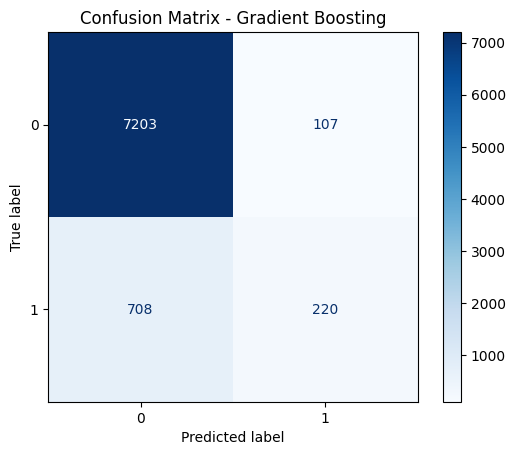

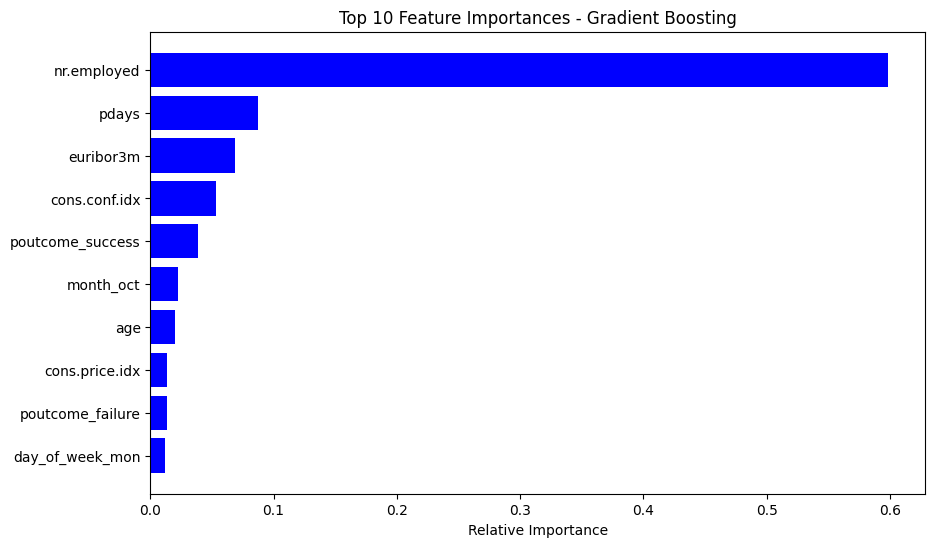

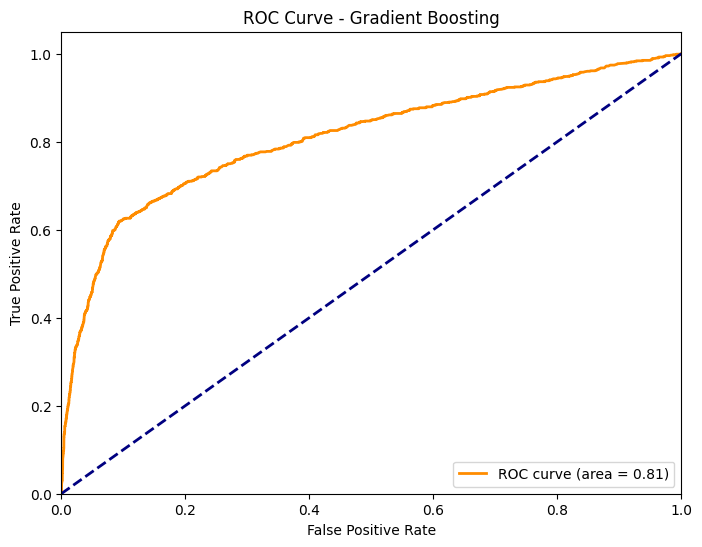

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
import os
import numpy as np
# Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_pipeline, X_test, y_test, cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))
plt.show()

# Feature Importance (hanya untuk Random Forest atau Gradient Boosting)
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    feature_names = (numeric_features +
                     list(best_pipeline.named_steps['preprocessor']
                          .named_transformers_['cat']
                          .named_steps['onehot']
                          .get_feature_names_out(categorical_features)))
    
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    indices = np.argsort(importances)[-10:]
    
    plt.figure(figsize=(10, 6))
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.barh(range(len(indices)), importances[indices], color='b', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.savefig(os.path.join(output_dir, 'feature_importance.png'))
    plt.show()

# ROC Curve
y_pred_proba_best = best_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc="lower right")
plt.savefig(os.path.join(output_dir, 'roc_curve.png'))
plt.show()